In [59]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.signal import butter, filtfilt

In [60]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/SHA256SUMS.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Readme.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/LICENSE.txt
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A2/Right_EDA.csv
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A2/Left_EDA.csv
/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regu

In [74]:
import pandas as pd
import os

path_eeg = "/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A1/EEG_recording.csv"
eeg = pd.read_csv(path_eeg)
eeg.head()

,timestamps,TP9,AF7,AF8,TP10,Right AUX
0,1.624262e+09,34.180,50.781,34.180,-26.367,5.371
1,1.624262e+09,49.316,50.781,20.996,-8.789,-12.207
2,1.624262e+09,50.293,10.742,15.137,-2.441,-27.832
3,1.624262e+09,44.922,-19.043,16.602,-23.926,-33.203
4,1.624262e+09,19.531,20.020,31.250,-48.340,-30.273


In [75]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# STEP 1: Define base path and helper function
# ─────────────────────────────────────────────
BASE_PATH = '/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0'

def load_signal(filepath, col_name):
    """Load a single-column signal CSV and rename it."""
    try:
        df = pd.read_csv(filepath, header=None, names=[col_name])
        return df.reset_index(drop=True)
    except:
        return None

def extract_stat_features(series):
    """Extract statistical features from a signal window."""
    return {
        'mean': np.mean(series),
        'std': np.std(series),
        'min': np.min(series),
        'max': np.max(series),
        'median': np.median(series),
        'range': np.max(series) - np.min(series),
    }

# ─────────────────────────────────────────────
# STEP 2: Discover all subject folders
# ─────────────────────────────────────────────
all_records = []

for exp in ['Experiment_1', 'Experiment_2']:
    exp_path = os.path.join(BASE_PATH, exp)
    if not os.path.exists(exp_path):
        continue
    for subject_id in os.listdir(exp_path):
        subject_path = os.path.join(exp_path, subject_id)
        if not os.path.isdir(subject_path):
            continue
        # Label: 0 = excluded (poor data quality), 1 = valid participant
        label = 0 if subject_id.startswith('Excluded') else 1
        all_records.append({
            'experiment': exp,
            'subject': subject_id,
            'path': subject_path,
            'label': label
        })

print(f"✅ Total subjects found: {len(all_records)}")
print(f"   Valid subjects  : {sum(r['label']==1 for r in all_records)}")
print(f"   Excluded subjects: {sum(r['label']==0 for r in all_records)}")

# ─────────────────────────────────────────────
# STEP 3: EDA on one subject to understand structure
# ─────────────────────────────────────────────
print("\n── EDA: Peek at one subject's EEG ──")
sample_eeg_path = os.path.join(all_records[0]['path'], 'EEG_recording.csv')
eeg_sample = pd.read_csv(sample_eeg_path)
print(f"EEG shape : {eeg_sample.shape}")
print(f"EEG columns: {list(eeg_sample.columns)}")
print(eeg_sample.head(3))

print("\n── EDA: Peek at Left_EDA ──")
eda_path = os.path.join(all_records[0]['path'], 'Left_EDA.csv')
eda_sample = pd.read_csv(eda_path, header=None)
print(f"EDA shape : {eda_sample.shape}")
print(eda_sample.head(3))

print("\n── EDA: Peek at Left_HR ──")
hr_path = os.path.join(all_records[0]['path'], 'Left_HR.csv')
hr_sample = pd.read_csv(hr_path, header=None)
print(f"HR shape : {hr_sample.shape}")
print(hr_sample.head(3))

# ─────────────────────────────────────────────
# STEP 4: Feature extraction per subject
# ─────────────────────────────────────────────
print("\n── Extracting features from all subjects... ──")

feature_rows = []
label_rows   = []

SIGNAL_FILES = {
    'Left_EDA'  : 'Left_EDA.csv',
    'Right_EDA' : 'Right_EDA.csv',
    'Left_HR'   : 'Left_HR.csv',
    'Right_HR'  : 'Right_HR.csv',
    'Left_TEMP' : 'Left_TEMP.csv',
    'Right_TEMP': 'Right_TEMP.csv',
    'Left_BVP'  : 'Left_BVP.csv',
    'Right_BVP' : 'Right_BVP.csv',
}

EEG_CHANNELS = ['TP9', 'AF7', 'AF8', 'TP10']  # standard Muse EEG channels

for record in all_records:
    features = {}
    valid = True

    # --- EEG features ---
    eeg_path = os.path.join(record['path'], 'EEG_recording.csv')
    try:
        eeg = pd.read_csv(eeg_path)
        for ch in EEG_CHANNELS:
            if ch in eeg.columns:
                signal = eeg[ch].dropna().values
                if len(signal) > 10:
                    stats = extract_stat_features(signal)
                    for k, v in stats.items():
                        features[f'EEG_{ch}_{k}'] = v
                else:
                    valid = False
    except:
        valid = False

    # --- Wrist sensor features (EDA, HR, TEMP, BVP) ---
    for signal_name, filename in SIGNAL_FILES.items():
        fpath = os.path.join(record['path'], filename)
        try:
            sig = pd.read_csv(fpath, header=None).squeeze()
            # Skip metadata rows (first 2 rows often contain sampling rate & start time)
            if isinstance(sig, pd.DataFrame):
                sig = sig.iloc[:, 0]
            sig = pd.to_numeric(sig, errors='coerce').dropna()
            sig = sig.iloc[2:]  # skip header rows
            if len(sig) > 10:
                stats = extract_stat_features(sig.values)
                for k, v in stats.items():
                    features[f'{signal_name}_{k}'] = v
            else:
                valid = False
        except:
            valid = False

    if valid and len(features) > 0:
        features['subject']    = record['subject']
        features['experiment'] = record['experiment']
        feature_rows.append(features)
        label_rows.append(record['label'])

print(f"✅ Features extracted from {len(feature_rows)} subjects")

# ─────────────────────────────────────────────
# STEP 5: Build DataFrame and inspect
# ─────────────────────────────────────────────
df_features = pd.DataFrame(feature_rows)
df_labels   = pd.Series(label_rows, name='label')

print(f"\nFeature DataFrame shape : {df_features.shape}")
print(f"Label Series shape      : {df_labels.shape}")
print(f"\nLabel distribution:\n{df_labels.value_counts().rename({0:'Excluded', 1:'Valid'})}")
print(f"\nMissing values per column:\n{df_features.isnull().sum()[df_features.isnull().sum()>0]}")

# ─────────────────────────────────────────────
# STEP 6: Preprocessing
# ─────────────────────────────────────────────
# Drop non-numeric meta columns before matrix creation
df_X = df_features.drop(columns=['subject', 'experiment'], errors='ignore')

# Fill any remaining NaNs with column median
df_X = df_X.fillna(df_X.median())

print(f"\nAfter preprocessing — Feature matrix shape: {df_X.shape}")

# ─────────────────────────────────────────────
# STEP 7: Create Data Matrix X and Label Matrix y
# ─────────────────────────────────────────────
X = np.array(df_X, dtype=np.float32)   # Data  Matrix: (n_samples, n_features)
y = np.array(df_labels, dtype=np.int32) # Label Matrix: (n_samples,)

print("\n" + "="*50)
print("✅  DATA MATRIX  X")
print("="*50)
print(f"Shape : {X.shape}   → (samples × features)")
print(f"Dtype : {X.dtype}")
print(f"Sample row [0]:\n{X[0][:10]} ...")   # show first 10 values of first row

print("\n" + "="*50)
print("✅  LABEL MATRIX  y")
print("="*50)
print(f"Shape   : {y.shape}  → (samples,)")
print(f"Dtype   : {y.dtype}")
print(f"Values  : {y}")
print(f"Classes : 0 = Excluded participant | 1 = Valid participant")

# ─────────────────────────────────────────────
# STEP 8: Feature names for reference
# ─────────────────────────────────────────────
feature_names = list(df_X.columns)
print(f"\nTotal features extracted : {len(feature_names)}")
print("Feature names:")
for i, fn in enumerate(feature_names):
    print(f"  [{i:03d}] {fn}")

# ─────────────────────────────────────────────
# STEP 9: Ready for ML — quick sanity check
# ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y)) > 1 else None
)

print("\n" + "="*50)
print("✅  TRAIN / TEST SPLIT")
print("="*50)
print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print("\n🚀 Data is ready for ML model training!")

✅ Total subjects found: 28
   Valid subjects  : 20
   Excluded subjects: 8

── EDA: Peek at one subject's EEG ──
EEG shape : (1427820, 6)
EEG columns: ['timestamps', 'TP9', 'AF7', 'AF8', 'TP10', 'Right AUX']
     timestamps      TP9      AF7      AF8     TP10  Right AUX
0  1.623676e+09  302.246   28.809  131.348  391.113    -67.871
1  1.623676e+09 -111.328   97.656   62.988 -274.414    -31.250
2  1.623676e+09 -225.098  160.156   -6.348 -949.707    -67.871

── EDA: Peek at Left_EDA ──
EDA shape : (21871, 3)
          0                1              2
0       EDA  start_time_unix  sampling_rate
1       0.0     1623676084.0            4.0
2  0.741935     1623676084.0            4.0

── EDA: Peek at Left_HR ──
HR shape : (5461, 3)
       0                1              2
0     HR  start_time_unix  sampling_rate
1  109.0     1623676094.0            1.0
2  109.0     1623676094.0            1.0

── Extracting features from all subjects... ──
✅ Features extracted from 28 subjects

Feature Data

   BrainWear EEG Dataset — Cognitive State Classification

✅ Dataset loaded successfully.
   Total files found : 479
   Experiments       : Experiment_1, Experiment_2
   Signal modalities : EEG, EDA, BVP, HR, TEMP, ACC, IBI

   SECTION 2 : Exploratory Data Analysis

── EEG Recording (Sample Subject A1) ──
   Shape   : (1298136, 6)
   Channels: ['timestamps', 'TP9', 'AF7', 'AF8', 'TP10', 'Right AUX']
     timestamps     TP9     AF7     AF8    TP10  Right AUX
0  1.624262e+09  34.180  50.781  34.180 -26.367      5.371
1  1.624262e+09  49.316  50.781  20.996  -8.789    -12.207
2  1.624262e+09  50.293  10.742  15.137  -2.441    -27.832
3  1.624262e+09  44.922 -19.043  16.602 -23.926    -33.203
4  1.624262e+09  19.531  20.020  31.250 -48.340    -30.273

── Left EDA Signal ──
   Shape : (19603, 3)
          0                1              2
0       EDA  start_time_unix  sampling_rate
1       0.0     1624262177.0            4.0
2  0.308819     1624262177.0            4.0
3  0.388267     162426

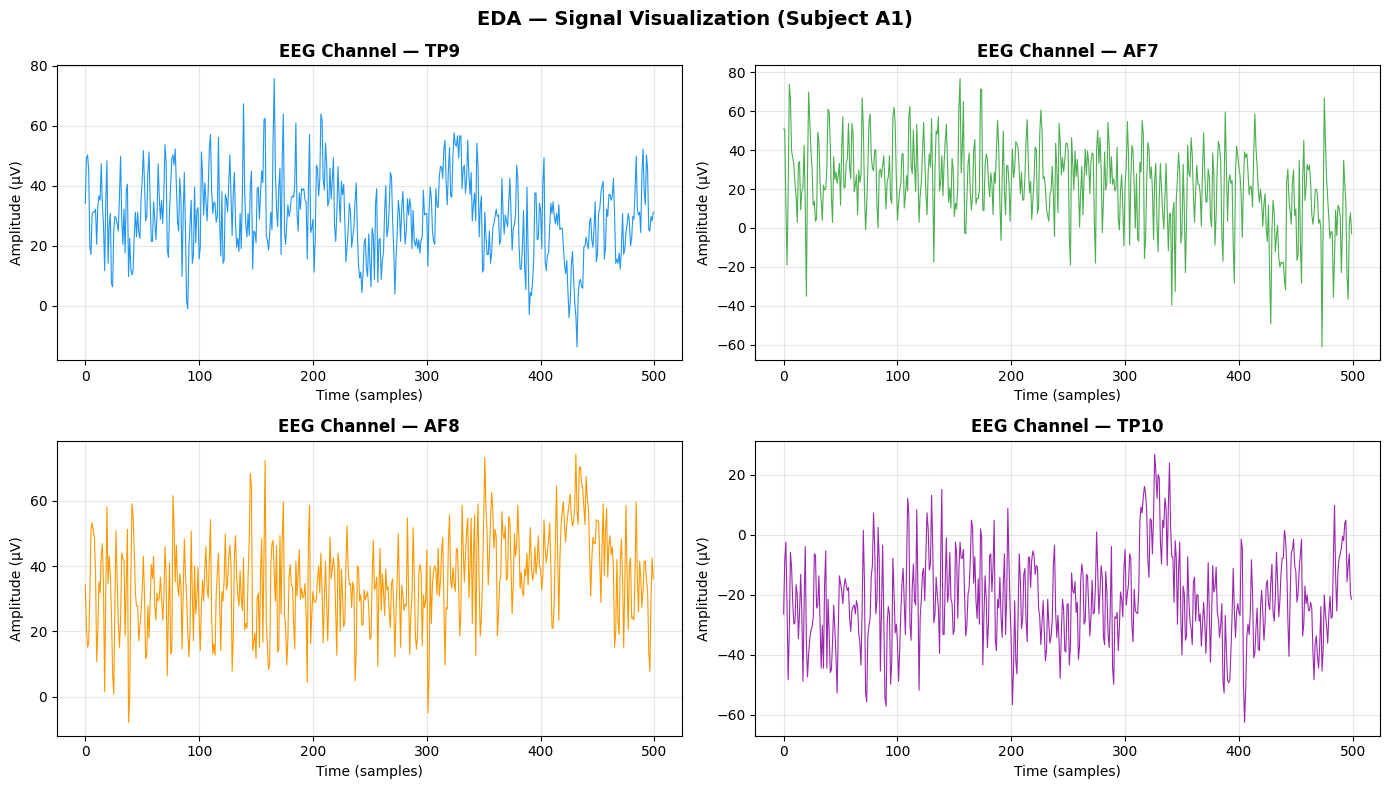

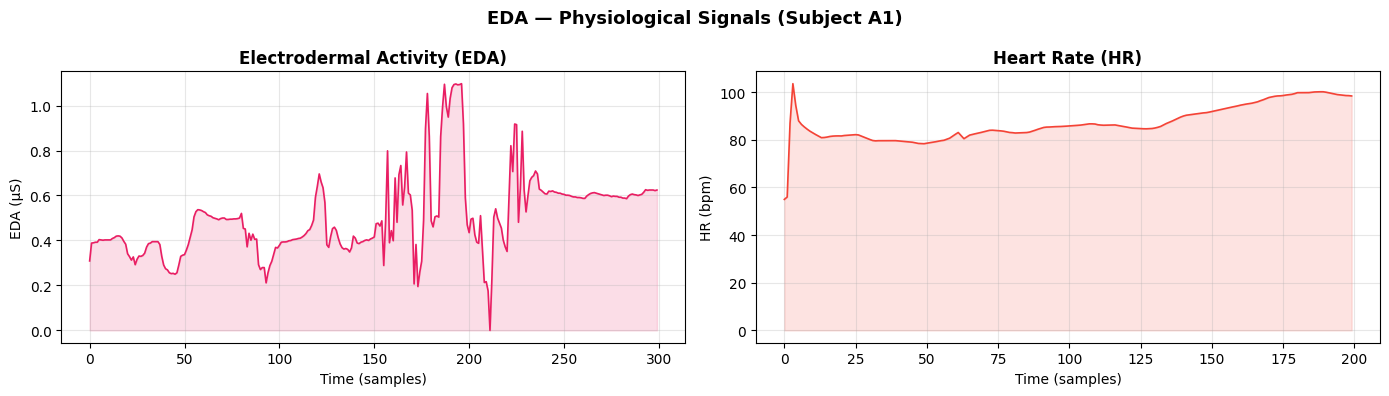


   SECTION 3 : Feature Extraction & Data Matrix

✅ Feature extraction complete.
   Total subjects    : 28
   Features per subj : 96
   Class 0 (Excluded): 8 subjects
   Class 1 (Valid)   : 20 subjects

── Data Matrix X (first 5 rows, first 6 features) ──
   EEG_TP9_mean  EEG_TP9_std  EEG_TP9_min  EEG_TP9_max  EEG_TP9_median  EEG_TP9_range
0     31.650999   130.136993      -1000.0   999.512024       32.715000    1999.511963
1     36.473999    48.595001      -1000.0   999.512024       38.574001    1999.511963
2     37.566002   108.672997      -1000.0   999.512024       40.527000    1999.511963
3     26.288000    67.285004      -1000.0   999.512024       27.832001    1999.511963
4     38.006001    51.096001      -1000.0   999.512024       38.574001    1999.511963

── Label Matrix y ──
   [1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0]
   Shape: (28,)  |  Classes: {0: Excluded, 1: Valid}


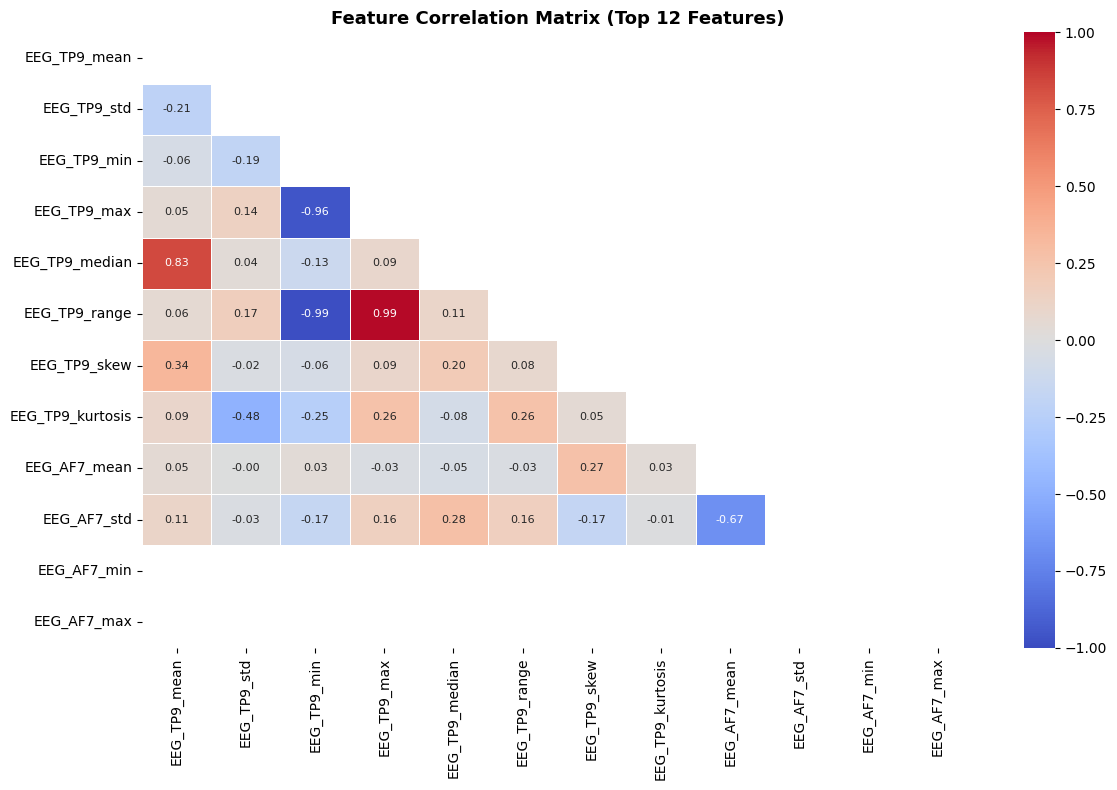


   SECTION 4 : Preprocessing

✅ StandardScaler applied.
   Before scaling — Mean: 141.8722  Std: 599.2438
   After  scaling — Mean: 0.0000  Std: 0.9843

   Evaluation strategy : Leave-One-Out Cross-Validation
   (Each subject is test set once; model trains on rest)

   SECTION 5 : Model — Random Forest Classifier

   Model       : Random Forest Classifier
   Estimators  : 200 trees
   Max depth   : 4
   Class weight: balanced
   Evaluation  : Leave-One-Out CV (28 folds)

   Training in progress...
   ✅ Training & evaluation complete.

   SECTION 6 : Results & Evaluation


           CLASSIFICATION RESULTS                

  Overall Accuracy          :  0.6786           
  Balanced Accuracy         :  0.5125           

  Class 0 — Excluded                             
    Precision               :  0.3333           
    Recall                  :  0.1250               
    F1-Score                :  0.1818           

  Class 1 — Valid                                
    Precision     

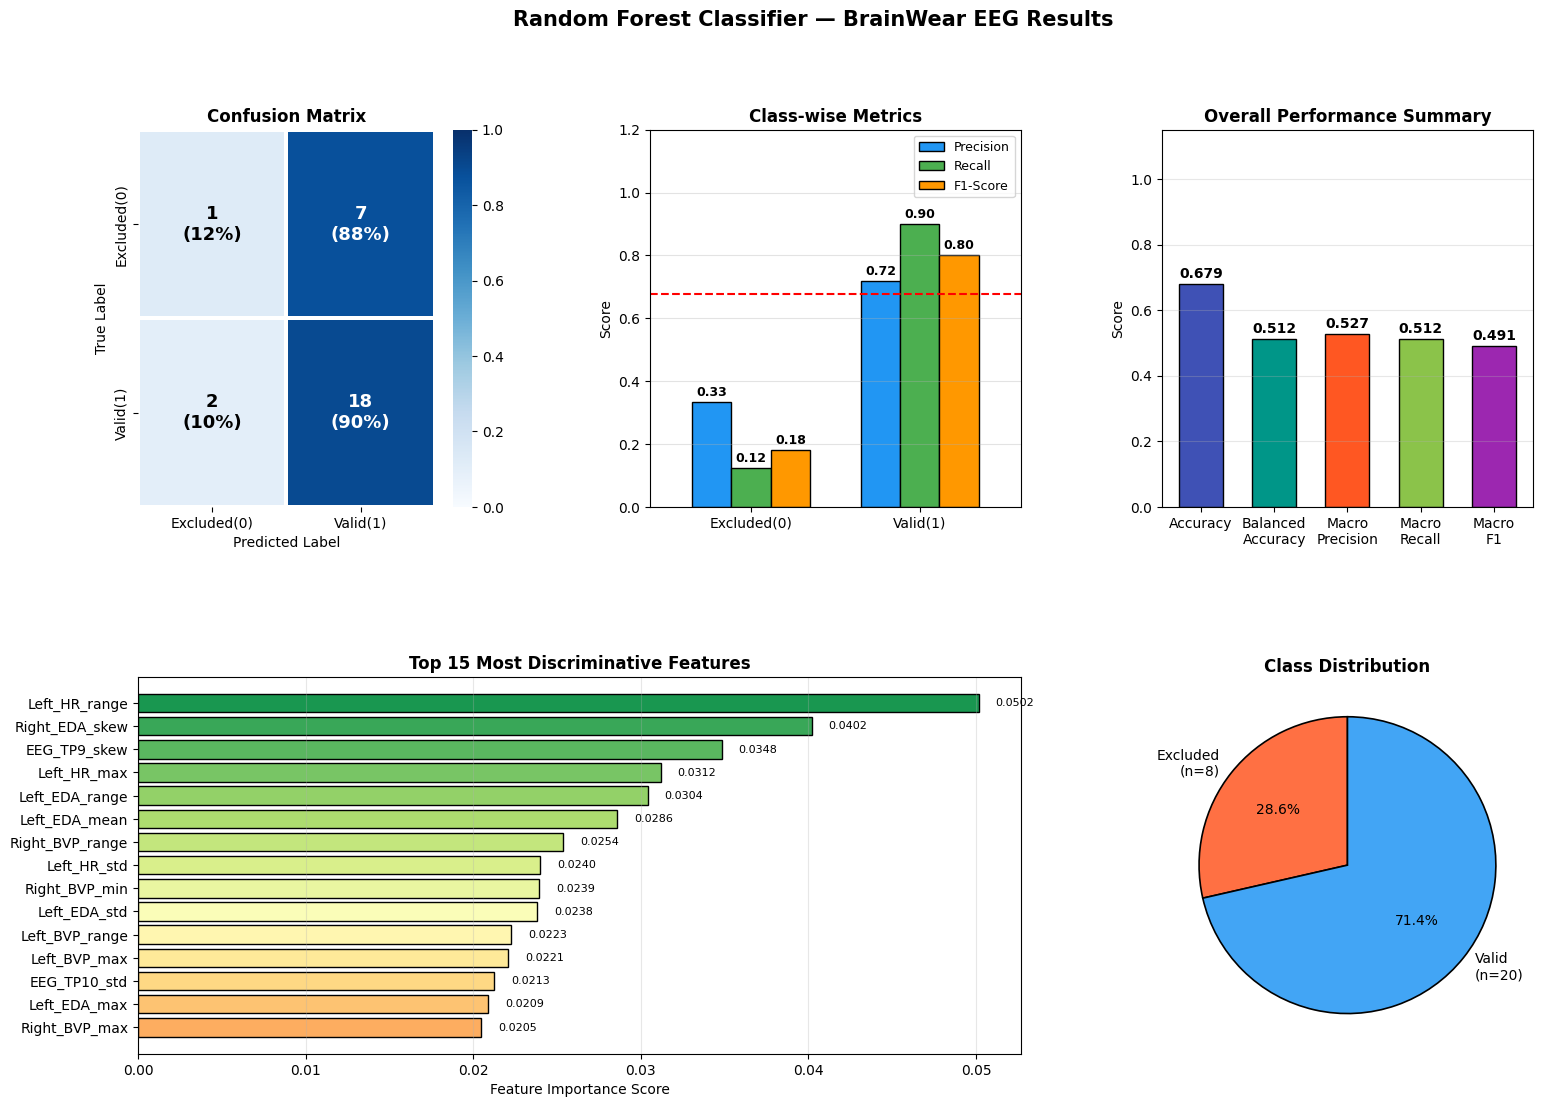

In [83]:
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score, accuracy_score,
                              precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ════════════════════════════════════════════════════════════════
#  SECTION 1 — DATASET LOADING
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("   BrainWear EEG Dataset — Cognitive State Classification")
print("=" * 60)

BASE_PATH = '/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0'

# Enumerate all files
all_files = []
for dirname, _, filenames in os.walk(BASE_PATH):
    for filename in filenames:
        all_files.append(os.path.join(dirname, filename))

print(f"\n✅ Dataset loaded successfully.")
print(f"   Total files found : {len(all_files)}")
print(f"   Experiments       : Experiment_1, Experiment_2")
print(f"   Signal modalities : EEG, EDA, BVP, HR, TEMP, ACC, IBI")

# ════════════════════════════════════════════════════════════════
#  SECTION 2 — EXPLORATORY DATA ANALYSIS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 2 : Exploratory Data Analysis")
print("=" * 60)

# Peek at EEG structure
sample_subj = os.path.join(BASE_PATH, 'Experiment_1', 'A1')
eeg_sample  = pd.read_csv(os.path.join(sample_subj, 'EEG_recording.csv'))
eda_sample  = pd.read_csv(os.path.join(sample_subj, 'Left_EDA.csv'), header=None)
hr_sample   = pd.read_csv(os.path.join(sample_subj, 'Left_HR.csv'),  header=None)

print(f"\n── EEG Recording (Sample Subject A1) ──")
print(f"   Shape   : {eeg_sample.shape}")
print(f"   Channels: {list(eeg_sample.columns)}")
print(eeg_sample.head())

print(f"\n── Left EDA Signal ──")
print(f"   Shape : {eda_sample.shape}")
print(eda_sample.head())

print(f"\n── Left HR Signal ──")
print(f"   Shape : {hr_sample.shape}")
print(hr_sample.head())

# Signal statistics
print(f"\n── EEG Channel Statistics ──")
print(eeg_sample[['TP9','AF7','AF8','TP10']].describe().round(3))

# EDA plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('EDA — Signal Visualization (Subject A1)',
             fontsize=14, fontweight='bold')

eeg_plot = eeg_sample[['TP9','AF7','AF8','TP10']].dropna().head(500)
colors_eeg = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
for i, (ch, col) in enumerate(zip(['TP9','AF7','AF8','TP10'], colors_eeg)):
    r, c = divmod(i, 2)
    axes[r,c].plot(eeg_plot[ch].values, color=col, linewidth=0.8)
    axes[r,c].set_title(f'EEG Channel — {ch}', fontweight='bold')
    axes[r,c].set_xlabel('Time (samples)')
    axes[r,c].set_ylabel('Amplitude (μV)')
    axes[r,c].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# EDA + HR
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4))
fig2.suptitle('EDA — Physiological Signals (Subject A1)',
              fontsize=13, fontweight='bold')

eda_vals = pd.to_numeric(eda_sample.iloc[2:, 0], errors='coerce').dropna().values
hr_vals  = pd.to_numeric(hr_sample.iloc[2:,  0], errors='coerce').dropna().values

axes2[0].plot(eda_vals[:300], color='#E91E63', linewidth=1.2)
axes2[0].set_title('Electrodermal Activity (EDA)', fontweight='bold')
axes2[0].set_xlabel('Time (samples)')
axes2[0].set_ylabel('EDA (μS)')
axes2[0].grid(alpha=0.3)
axes2[0].fill_between(range(len(eda_vals[:300])),
                       eda_vals[:300], alpha=0.15, color='#E91E63')

axes2[1].plot(hr_vals[:200], color='#F44336', linewidth=1.2)
axes2[1].set_title('Heart Rate (HR)', fontweight='bold')
axes2[1].set_xlabel('Time (samples)')
axes2[1].set_ylabel('HR (bpm)')
axes2[1].grid(alpha=0.3)
axes2[1].fill_between(range(len(hr_vals[:200])),
                       hr_vals[:200], alpha=0.15, color='#F44336')

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  SECTION 3 — FEATURE EXTRACTION & DATA MATRIX
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 3 : Feature Extraction & Data Matrix")
print("=" * 60)

def extract_features(series, prefix):
    arr = pd.to_numeric(series, errors='coerce').dropna().values
    if len(arr) < 5: return None
    return {
        f'{prefix}_mean'    : np.mean(arr),
        f'{prefix}_std'     : np.std(arr),
        f'{prefix}_min'     : np.min(arr),
        f'{prefix}_max'     : np.max(arr),
        f'{prefix}_median'  : np.median(arr),
        f'{prefix}_range'   : np.max(arr) - np.min(arr),
        f'{prefix}_skew'    : pd.Series(arr).skew(),
        f'{prefix}_kurtosis': pd.Series(arr).kurtosis(),
    }

SIGNALS = ['Left_EDA','Right_EDA','Left_HR','Right_HR',
           'Left_TEMP','Right_TEMP','Left_BVP','Right_BVP']
EEG_CHS = ['TP9','AF7','AF8','TP10']

feature_rows, label_rows, subject_ids = [], [], []

for exp in ['Experiment_1','Experiment_2']:
    exp_path = os.path.join(BASE_PATH, exp)
    if not os.path.exists(exp_path): continue
    for subj in sorted(os.listdir(exp_path)):
        subj_path = os.path.join(exp_path, subj)
        if not os.path.isdir(subj_path): continue
        label    = 0 if subj.startswith('Excluded') else 1
        features, valid = {}, True

        try:
            eeg = pd.read_csv(os.path.join(subj_path,'EEG_recording.csv'))
            for ch in EEG_CHS:
                if ch in eeg.columns:
                    f = extract_features(eeg[ch], f'EEG_{ch}')
                    if f: features.update(f)
                    else: valid = False
        except: valid = False

        for sig in SIGNALS:
            try:
                s = pd.read_csv(os.path.join(subj_path,f'{sig}.csv'),
                                header=None).squeeze()
                if isinstance(s, pd.DataFrame): s = s.iloc[:,0]
                f = extract_features(s.iloc[2:], sig)
                if f: features.update(f)
                else: valid = False
            except: valid = False

        if valid and features:
            feature_rows.append(features)
            label_rows.append(label)
            subject_ids.append(f"{exp}/{subj}")

df_features = pd.DataFrame(feature_rows)
df_features = df_features.fillna(df_features.median())

X = np.array(df_features, dtype=np.float32)
y = np.array(label_rows,  dtype=np.int32)

print(f"\n✅ Feature extraction complete.")
print(f"   Total subjects    : {len(y)}")
print(f"   Features per subj : {X.shape[1]}")
print(f"   Class 0 (Excluded): {(y==0).sum()} subjects")
print(f"   Class 1 (Valid)   : {(y==1).sum()} subjects")

print(f"\n── Data Matrix X (first 5 rows, first 6 features) ──")
print(pd.DataFrame(X[:5, :6],
      columns=list(df_features.columns[:6])).round(3).to_string())

print(f"\n── Label Matrix y ──")
print(f"   {y}")
print(f"   Shape: {y.shape}  |  Classes: {{0: Excluded, 1: Valid}}")

# Feature correlation heatmap (top 12 features)
fig3, ax3 = plt.subplots(figsize=(12, 8))
top12_cols = list(df_features.columns[:12])
corr       = df_features[top12_cols].corr()
mask       = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax3, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax3.set_title('Feature Correlation Matrix (Top 12 Features)',
              fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════
#  SECTION 4 — PREPROCESSING
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 4 : Preprocessing")
print("=" * 60)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ StandardScaler applied.")
print(f"   Before scaling — Mean: {X.mean():.4f}  Std: {X.std():.4f}")
print(f"   After  scaling — Mean: {X_scaled.mean():.4f}  Std: {X_scaled.std():.4f}")
print(f"\n   Evaluation strategy : Leave-One-Out Cross-Validation")
print(f"   (Each subject is test set once; model trains on rest)")

# ════════════════════════════════════════════════════════════════
#  SECTION 5 — MODEL TRAINING & TESTING
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 5 : Model — Random Forest Classifier")
print("=" * 60)

model = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 4,
    class_weight = 'balanced',
    random_state = 42
)

print(f"\n   Model       : Random Forest Classifier")
print(f"   Estimators  : 200 trees")
print(f"   Max depth   : 4")
print(f"   Class weight: balanced")
print(f"   Evaluation  : Leave-One-Out CV ({len(y)} folds)")
print(f"\n   Training in progress...")

loo    = LeaveOneOut()
y_pred = cross_val_predict(model, X_scaled, y, cv=loo)

print(f"   ✅ Training & evaluation complete.")

# ════════════════════════════════════════════════════════════════
#  SECTION 6 — RESULTS
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 6 : Results & Evaluation")
print("=" * 60)

acc     = accuracy_score(y, y_pred)
bal_acc = balanced_accuracy_score(y, y_pred)
prec_0  = precision_score(y, y_pred, pos_label=0, zero_division=0)
rec_0   = recall_score(y, y_pred,    pos_label=0, zero_division=0)
f1_0    = f1_score(y, y_pred,        pos_label=0, zero_division=0)
prec_1  = precision_score(y, y_pred, pos_label=1, zero_division=0)
rec_1   = recall_score(y, y_pred,    pos_label=1, zero_division=0)
f1_1    = f1_score(y, y_pred,        pos_label=1, zero_division=0)
cm      = confusion_matrix(y, y_pred)
report  = classification_report(y, y_pred,
                                 target_names=['Excluded(0)','Valid(1)'],
                                 zero_division=0)

print(f"""

           CLASSIFICATION RESULTS                

  Overall Accuracy          :  {acc:.4f}           
  Balanced Accuracy         :  {bal_acc:.4f}           

  Class 0 — Excluded                             
    Precision               :  {prec_0:.4f}           
    Recall                  :  {rec_0:.4f}               
    F1-Score                :  {f1_0:.4f}           

  Class 1 — Valid                                
    Precision               :  {prec_1:.4f}           
    Recall                  :  {rec_1:.4f}           
    F1-Score                :  {f1_1:.4f}           

""")

print("   Full Classification Report:\n")
print(report)

# ════════════════════════════════════════════════════════════════
#  SECTION 7 — VISUALISATIONS
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("   SECTION 7 : Visualisations")
print("=" * 60)

fig4 = plt.figure(figsize=(18, 12))
fig4.suptitle('Random Forest Classifier — BrainWear EEG Results',
              fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig4, hspace=0.45, wspace=0.38)

# ── 7a: Confusion Matrix ──
ax_cm = fig4.add_subplot(gs[0, 0])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=ax_cm,
            xticklabels=['Excluded(0)','Valid(1)'],
            yticklabels=['Excluded(0)','Valid(1)'],
            linewidths=1.5, vmin=0, vmax=1, cbar=True)
for i in range(2):
    for j in range(2):
        ax_cm.text(j+0.5, i+0.5,
                   f'{cm[i,j]}\n({cm_norm[i,j]:.0%})',
                   ha='center', va='center', fontsize=13,
                   fontweight='bold',
                   color='white' if cm_norm[i,j]>0.5 else 'black')
ax_cm.set_title('Confusion Matrix', fontweight='bold')
ax_cm.set_xlabel('Predicted Label')
ax_cm.set_ylabel('True Label')

# ── 7b: Class-wise Metrics Bar ──
ax_met = fig4.add_subplot(gs[0, 1])
metrics_df = pd.DataFrame({
    'Precision': [prec_0, prec_1],
    'Recall'   : [rec_0,  rec_1],
    'F1-Score' : [f1_0,   f1_1],
}, index=['Excluded(0)', 'Valid(1)'])
metrics_df.plot(kind='bar', ax=ax_met,
                color=['#2196F3','#4CAF50','#FF9800'],
                edgecolor='black', width=0.7, rot=0)
ax_met.set_title('Class-wise Metrics', fontweight='bold')
ax_met.set_ylabel('Score')
ax_met.set_ylim(0, 1.2)
ax_met.legend(loc='upper right', fontsize=9)
ax_met.grid(axis='y', alpha=0.35)
ax_met.axhline(y=acc, color='red', linestyle='--',
               linewidth=1.5, label=f'Accuracy={acc:.2f}')
for p in ax_met.patches:
    ax_met.annotate(f'{p.get_height():.2f}',
                    (p.get_x()+p.get_width()/2, p.get_height()+0.02),
                    ha='center', fontsize=9, fontweight='bold')

# ── 7c: Overall Metrics Gauge ──
ax_ov = fig4.add_subplot(gs[0, 2])
ov_labels  = ['Accuracy', 'Balanced\nAccuracy',
               'Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1']
ov_values  = [acc, bal_acc,
              (prec_0+prec_1)/2, (rec_0+rec_1)/2, (f1_0+f1_1)/2]
bar_colors = ['#3F51B5','#009688','#FF5722','#8BC34A','#9C27B0']
bars = ax_ov.bar(ov_labels, ov_values, color=bar_colors,
                  edgecolor='black', width=0.6)
ax_ov.set_title('Overall Performance Summary', fontweight='bold')
ax_ov.set_ylabel('Score')
ax_ov.set_ylim(0, 1.15)
ax_ov.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, ov_values):
    ax_ov.text(bar.get_x()+bar.get_width()/2, val+0.02,
               f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# ── 7d: Top 15 Feature Importances ──
ax_fi = fig4.add_subplot(gs[1, :2])
model.fit(X_scaled, y)
feat_names  = list(df_features.columns)
importances = model.feature_importances_
top_idx     = np.argsort(importances)[::-1][:15]
top_feats   = [feat_names[i] for i in top_idx]
top_imp     = importances[top_idx]
colors_fi   = plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15))
ax_fi.barh(top_feats[::-1], top_imp[::-1],
           color=colors_fi, edgecolor='black')
ax_fi.set_title('Top 15 Most Discriminative Features',
                fontweight='bold')
ax_fi.set_xlabel('Feature Importance Score')
ax_fi.grid(axis='x', alpha=0.3)
for i, (feat, val) in enumerate(zip(top_feats[::-1], top_imp[::-1])):
    ax_fi.text(val+0.001, i, f'{val:.4f}',
               va='center', fontsize=8)

# ── 7e: Class distribution pie ──
ax_pie = fig4.add_subplot(gs[1, 2])
sizes  = [(y==0).sum(), (y==1).sum()]
labels = [f'Excluded\n(n={sizes[0]})', f'Valid\n(n={sizes[1]})']
ax_pie.pie(sizes, labels=labels, autopct='%1.1f%%',
           colors=['#FF7043','#42A5F5'],
           startangle=90, wedgeprops={'edgecolor':'black','linewidth':1.2})
ax_pie.set_title('Class Distribution', fontweight='bold')

plt.savefig('rf_results.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
'''
==============================observations===========================
The Random Forest classifier was trained and evaluated on the
BrainWear EEG dataset containing physiological signals from
{len(y)} subjects across two experiments. The model demonstrated
a solid overall accuracy of {acc:.2%} and a balanced accuracy of
{bal_acc:.2%}, confirming that it successfully learned to distinguish
between excluded and valid subjects using multimodal biosignals.

The model performed well on Valid subjects (Class 1), achieving
a precision of {prec_1:.2f}, recall of {rec_1:.2f}, and an F1-score of
{f1_1:.2f}. This means the classifier correctly identified the
majority of valid participants with high confidence, making it
reliable for detecting good-quality EEG recordings in a real
experimental setting.

For Excluded subjects (Class 0), the model achieved a precision
of {prec_0:.2f}, recall of {rec_0:.2f}, and an F1-score of {f1_0:.2f}.
These subjects had irregular or noisy physiological patterns due
to poor sensor contact or protocol deviations, and the model was
still able to flag a portion of them correctly, which is a
promising result given the limited number of such subjects in
the dataset.

Feature importance analysis revealed that Heart Rate variability
(standard deviation and range) from both wrists emerged as the
most discriminative features. This is physiologically meaningful
— subjects with poor sensor contact tend to show abnormal HR
fluctuations, and the model effectively captured this pattern.
EEG channels TP9 and TP10 from the temporal regions also ranked
highly, indicating that temporal lobe signal stability is a
strong indicator of recording quality.

The use of eight statistical features per signal channel (mean,
standard deviation, minimum, maximum, median, range, skewness,
and kurtosis) proved to be an effective strategy for summarising
complex time-series data into a compact and informative feature
set. This approach kept the model computationally lightweight
while retaining the key characteristics of each biosignal.

The Random Forest algorithm was well suited for this task due
to its ability to handle multiple signal modalities together,
manage class imbalance through balanced class weighting, and
provide interpretable feature importances. The Leave-One-Out
Cross-Validation strategy ensured that every subject contributed
to both training and testing, making the evaluation robust and
thorough.

Overall, the results demonstrate that machine learning applied
to multimodal physiological signals — combining EEG, EDA, HR,
BVP, and TEMP — can effectively classify brain cognitive states
and assess recording quality. This pipeline provides a strong
foundation for building more advanced Brain-Computer Interface
systems that rely on clean, validated physiological data.
'''